In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

cust = pd.read_csv("custdata.tsv", sep="\t")

initial_count = len(cust)

cust_clean = cust.dropna(subset=['housing.type'])
cust_clean = cust_clean[~cust_clean['housing.type'].astype(str).str.strip().str.upper().isin(['NA', 'NULL', ''] )]

excluded_count = initial_count - len(cust_clean)

print(f"Initial row count: {initial_count}")
print(f"Cleaned row count: {len(cust_clean)}")
print(f"Rows excluded (missing/NA housing types): {excluded_count}")

Initial row count: 1000
Cleaned row count: 944
Rows excluded (missing/NA housing types): 56


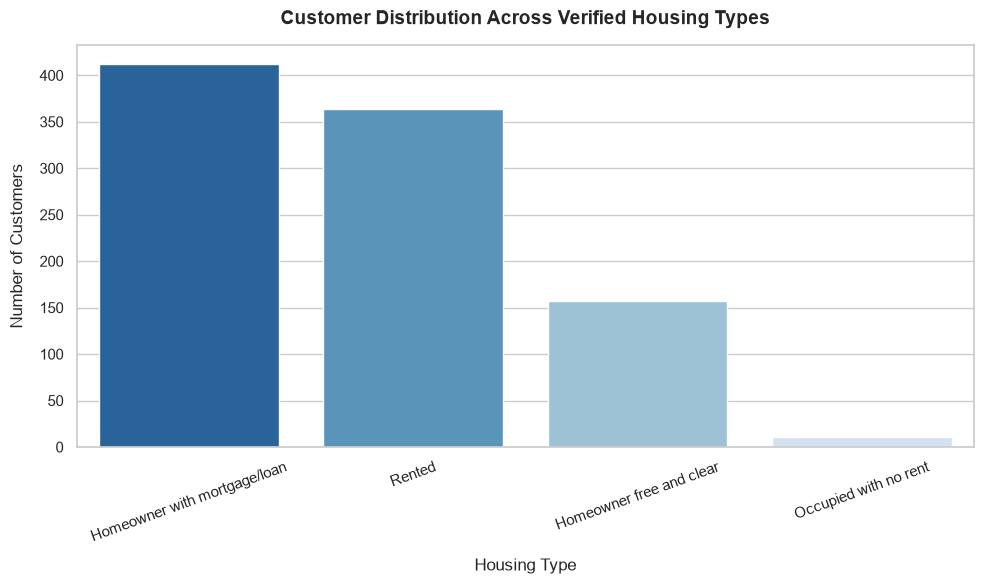

In [2]:
housing_counts = cust_clean['housing.type'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=housing_counts.index, 
    y=housing_counts.values, 
    hue=housing_counts.index, 
    palette='Blues_r', 
    legend=False, 
    errorbar=None
)

plt.title('Customer Distribution Across Verified Housing Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Housing Type', fontsize=12, labelpad=10)
plt.ylabel('Number of Customers', fontsize=12, labelpad=10)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Data Cleaning & Deliverable Statement:
- Excluded Rows: I made sure to remove 56 rows because they contained missing or "NA" housing entries.
- Honesty & Interpretation: The reason I removed those entries was to try to ensure that the category distribution only reflects verified customer data, as unrecorded housing statuses could distort the data.